## Turtle Games – Customer & Loyalty Analytics

**LSE Data Analytics Career Accelerator | DA301: Advanced Analytics for Organisational Impact**

Analysed 2,000 customer records using Python, including linear regression, decision trees, K-means clustering and NLP, to identify loyalty drivers, customer segments and actionable marketing opportunities.

### Business Context
Turtle Games is a global game manufacturer and retailer looking to improve sales performance by better understanding customer behaviour and loyalty. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- identify the main drivers of loyalty-point accumulation;
- explore customer behaviour using decision trees;
- identify meaningful customer segments using K-means clustering;
- assess whether customer reviews can support marketing decisions;
- extend the analysis using R for exploratory analysis and statistical modelling.

# 1. Linear Regression – Loyalty Drivers
The marketing department of Turtle Games prefers Python for data analysis. As you are fluent in Python, they asked you to assist with data analysis of social media data. The marketing department wants to better understand how users accumulate loyalty points. Therefore, you need to investigate the possible relationships between the loyalty points, age, remuneration, and spending scores. Note that you will use this data set in future modules as well and it is, therefore, strongly encouraged to first clean the data as per provided guidelines and then save a copy of the clean data for future use.

## Instructions
1. Load and explore the data.
    1. Create a new DataFrame (e.g. reviews).
    2. Sense-check the DataFrame.
    3. Determine if there are any missing values in the DataFrame.
    4. Create a summary of the descriptive statistics.
2. Remove redundant columns (`language` and `platform`).
3. Change column headings to names that are easier to reference (e.g. `remuneration` and `spending_score`).
4. Save a copy of the clean DataFrame as a CSV file. Import the file to sense-check.
5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/emuneration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.
6. Include your insights and observations.

## 1. Load and explore the data

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from statsmodels.formula.api import ols

In [2]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv("turtle_reviews.csv")

# View the DataFrame.
reviews

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,EN,Web,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,EN,Web,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,EN,Web,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,EN,Web,1031,fun game!,Four Stars


In [3]:
# Any missing values?
reviews.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

In [4]:
# Explore the data.
reviews.head()
reviews.tail()
reviews.shape
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [5]:
# Basic descriptive statistics.
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Drop columns

In [6]:
# Drop unnecessary columns.
reviews = reviews.drop(columns=["language", "platform"])

# View column names.
reviews.columns

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')

## 3. Rename columns

In [7]:
# Rename the column headers.

reviews = reviews.rename(columns={
    "remuneration (k£)": "remuneration",
    "spending_score (1–100)": "spending_score"})


# View column names.
reviews.columns

Index(['gender', 'age', 'remuneration', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')

## 4. Save the DataFrame as a CSV file

In [8]:
# Create a CSV file as output.

reviews.to_csv("turtle_reviews_clean.csv", index=False)

In [9]:
# Import new CSV file with Pandas.
reviews_clean = pd.read_csv("turtle_reviews_clean.csv")

# View DataFrame.
reviews_clean

,gender,age,remuneration,spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap
...,...,...,...,...,...,...,...,...,...
1995,Female,37,84.46,69,4031,PhD,977,The perfect word game for mixed ages (with Mom...,The perfect word game for mixed ages (with Mom
1996,Female,43,92.66,8,539,PhD,979,Great game. Did not think I would like it whe...,Super fun
1997,Male,34,92.66,91,5614,graduate,1012,Great game for all.........\nKeeps the mind ni...,Great Game
1998,Male,34,98.40,16,1048,PhD,1031,fun game!,Four Stars


## 5. Linear regression

### 5a) spending vs loyalty

In [10]:
# Import statsmodels.
import statsmodels.api as sm
# Define independent variable.
X = reviews_clean["spending_score (1-100)"]

# Define dependent variable.
y = reviews_clean["loyalty_points"]

# Create model and print summary of metrics.
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          2.92e-263
Time:                        13:04:55   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                    -75

**Interpretation:**

The coefficient for spending_score is 33.0617. This means that, on average, **a one-point increase in spending score is associated with approximately 33 additional loyalty points.**

**The R-squared value is 0.452.**
This means that spending score explains approximately 45.2% of the variation in customers’ loyalty points.

Because the p-value is below 0.05, the relationship between spending score and loyalty points is **statistically significant.**

**A skewness of 0.422** indicates that the residuals are moderately positively skewed. **Kurtosis above 3 indicates heavier tails than a normal distribution**, possibly caused by customers with unusually high or low loyalty-point values.

In [11]:
# Extract the estimated parameters.
estimated_parameters = model.params

# Extract the standard errors.
standard_errors = model.bse 

# Extract the predicted values.
predicted_values = model.predict(X)
################################################
# View the estimated parameters.
print(estimated_parameters)

# View the standard errors.
print(standard_errors)

# View the first predicted values.
print(predicted_values.head())

const                    -75.052663
spending_score (1-100)    33.061693
dtype: float64
const                     45.930554
spending_score (1-100)     0.814419
dtype: float64
0    1214.353374
1    2602.944491
2     123.317497
3    2470.697718
4    1247.415067
dtype: float64


In [12]:
# Set the X coefficient and the constant to generate the regression table.
x_coefficient = model.params["spending_score (1-100)"]
constant = model.params["const"]

regression_table = pd.DataFrame({
    "spending_score": reviews_clean["spending_score (1-100)"],
    "loyalty_points": reviews_clean["loyalty_points"],
    "predicted_loyalty_points": (
        constant + x_coefficient * reviews_clean["spending_score (1-100)"])})

# View the output.
regression_table.head()

,spending_score,loyalty_points,predicted_loyalty_points
0,39,210,1214.353374
1,81,524,2602.944491
2,6,40,123.317497
3,77,562,2470.697718
4,40,366,1247.415067


**The model calculates predictions using:**

Predicted loyalty points = −75.0527 + 33.0617 × spending score

Therefore, based on the general relationship in the whole dataset, a customer with a spending score of 39 is expected to have approximately **1,214 loyalty points**. However, this particular customer has only **210 points.**

Because the model’s Rˆ2 is **0.452**, spending score explains only **45.2% of the differences in loyalty points.** 
Large differences between actual and predicted values are therefore expected.

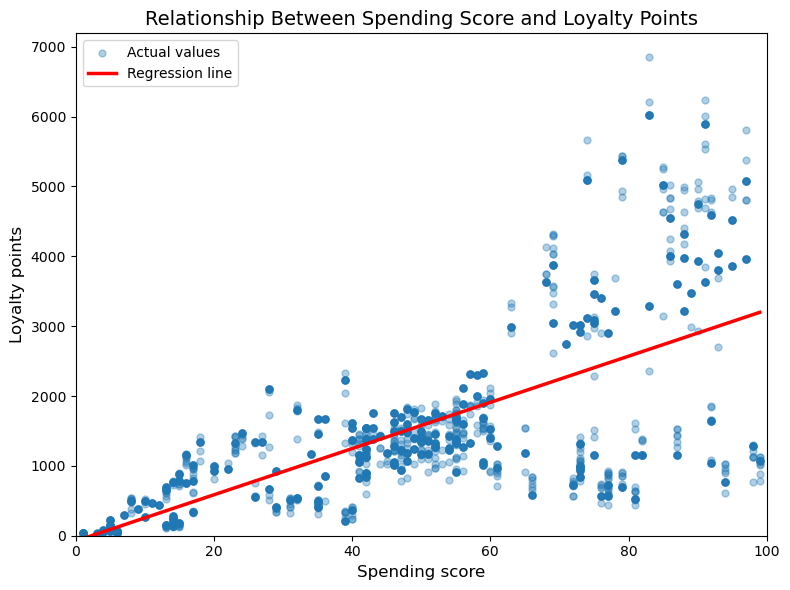

In [13]:
# Plot the graph with a regression line.
# Sort the regression table so the regression line is drawn correctly.

regression_table_sorted = regression_table.sort_values("spending_score")

# Create a larger figure.
plt.figure(figsize=(8, 6))

# Plot the actual data points.
plt.scatter(
    regression_table["spending_score"],
    regression_table["loyalty_points"],
    alpha=0.35,
     s=25,
    label="Actual values")

# Plot the regression line.
plt.plot(
    regression_table_sorted["spending_score"],
    regression_table_sorted["predicted_loyalty_points"],
     color="red",
    linewidth=2.5,
    label="Regression line")

# Add labels and title.
plt.xlabel("Spending score")
plt.ylabel("Loyalty points")
plt.title("Relationship between spending score and loyalty points")
plt.xlabel("Spending score", fontsize=12)
plt.ylabel("Loyalty points", fontsize=12)
plt.title("Relationship Between Spending Score and Loyalty Points", fontsize=14)
plt.legend()

# Set appropriate axis limits.
plt.xlim(0, 100)
plt.ylim(bottom=0)


plt.legend()

# Improve spacing.
plt.tight_layout()

# Display the graph.
plt.show()

**Main conclusions**

1. **Spending score is a useful predictor.**
The red regression line rises from left to right. Based on the model, each additional spending-score point is associated with approximately 33 extra loyalty points on average.

3. **The relationship is only moderately strong.**
The model’s Rˆ2 is 0.452, so spending score explains about 45.2% of the variation in loyalty points.

4. **Predictions are more consistent at lower spending scores.**
For spending scores below approximately 20, the points are relatively close together and near the regression line. Loyalty-point accumulation appears more predictable for these customers.

5. **Variation increases at higher spending scores.**
At spending scores above approximately 60, the points spread widely—from fewer than 1,000 loyalty points to more than 6,000.
This widening spread suggests heteroscedasticity: the model’s prediction errors become larger as spending score increases.

6. **High-spending customers appear to form different groups.**
Among customers with spending scores between roughly 70 and 100, there seem to be at least two visible groups:
customers with relatively low loyalty points, often around 500–1,500;
customers with very high loyalty points, often around 3,000–6,000.


This may indicate different customer segments. For example, some high-spending customers may purchase frequently, while others may make fewer but larger purchases.

### 5b) remuneration vs loyalty

In [14]:
# Define independent variable.
X = reviews_clean["remuneration"]

# Define dependent variable.
y = reviews_clean["loyalty_points"]

# Add a constant to calculate the intercept.
X = sm.add_constant(X)

# Create model and print summary of metrics.
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          2.43e-209
Time:                        13:04:55   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -65.6865     52.171     -1.259   

**Interpretation:**

1. Predicted loyalty points = −65.6865 + 34.1878 × remuneration

Remuneration is measured in thousands of pounds. 
Therefore, an increase of **£1,000 in annual remuneration** is associated with approximately **34.19 additional loyalty points**, on average.

2. R-squared = 0.380
   This means remuneration explains approximately **38% of the variation in loyalty points.**

3. The p-value is below 0.05, so remuneration is a **statistically significant predictor** of loyalty points.

In [15]:
# Extract the estimated parameters.
estimated_parameters = model.params

# Extract the standard errors.
standard_errors = model.bse

# Extract the predicted values.
predicted_values = model.predict(X)
######################################################################
# View the estimated parameters.
print(estimated_parameters)

# View the standard errors.
print(standard_errors)

# View the first five predicted values.
print(predicted_values.head())

const          -65.686513
remuneration    34.187825
dtype: float64
const           52.170717
remuneration     0.977925
dtype: float64
0    354.823741
1    354.823741
2    382.857758
3    382.857758
4    410.891774
dtype: float64


In [16]:
# Set the the X coefficient and the constant to generate the regression table.
x_coefficient = model.params["remuneration"]
constant = model.params["const"]

regression_table = pd.DataFrame({
    "remuneration": reviews_clean["remuneration"],
    "loyalty_points": reviews_clean["loyalty_points"],
    "predicted_loyalty_points": (
        constant + x_coefficient * reviews_clean["remuneration"])})

# View the output.
regression_table.head()

,remuneration,loyalty_points,predicted_loyalty_points
0,12.30,210,354.823741
1,12.30,524,354.823741
2,13.12,40,382.857758
3,13.12,562,382.857758
4,13.94,366,410.891774


**Why do customers 0 and 1 have the same prediction?**

Both have remuneration of £12,300, so the model gives both the same predicted value:
354.82
However, their actual loyalty points differ:
Customer 0: 210
Customer 1: 524
This happens because the model uses only remuneration. It does not consider spending score, age, purchasing frequency, product choice, or other customer behaviour.
Main interpretation
The model predicts the average loyalty-points value expected for each remuneration level. It does not predict every individual customer exactly.
Because remuneration explains only 38% of the variation in loyalty points, differences between actual and predicted values are expected.

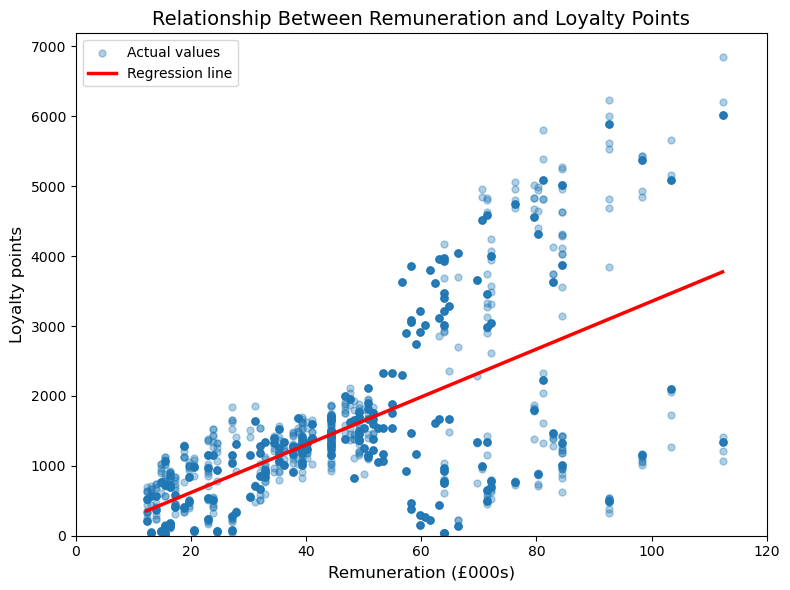

In [17]:
# Plot graph with regression line.
# Sort the regression table so the regression line is drawn correctly.
regression_table_sorted = regression_table.sort_values("remuneration")

# Create a larger figure.
plt.figure(figsize=(8, 6))

# Plot the actual data points.
plt.scatter(
    regression_table["remuneration"],
    regression_table["loyalty_points"],
    alpha=0.35,
    s=25,
    label="Actual values")

# Plot the regression line.
plt.plot(
    regression_table_sorted["remuneration"],
    regression_table_sorted["predicted_loyalty_points"],
    color="red",
    linewidth=2.5,
    label="Regression line")

# Add labels and title.
plt.xlabel("Remuneration (£000s)", fontsize=12)
plt.ylabel("Loyalty points", fontsize=12)
plt.title(
    "Relationship Between Remuneration and Loyalty Points",
    fontsize=14)

# Set appropriate axis limits.
plt.xlim(0, 120)
plt.ylim(bottom=0)

# Add the legend.
plt.legend()

# Improve spacing.
plt.tight_layout()

# Display the graph.
plt.show()

**Main observations**

1. **Positive linear trend.**
The red regression line slopes upward. Based on the model, every additional £1,000 of annual remuneration is associated with approximately 34 additional loyalty points, on average.

2. **The relationship is moderate, not strong.**
The points are widely dispersed around the regression line. The model’s Rˆ2 is 0.380, meaning remuneration explains approximately 38% of the variation in loyalty points.

3. **Predictions are more consistent at lower remuneration levels.**
At remuneration levels below approximately £50,000, the observations are more concentrated. The relationship appears clearer and loyalty points are generally lower.

4. **Variation increases among higher-income customers.**
Above approximately £55,000–£60,000, customers with similar remuneration have very different loyalty-point totals.

For example, customers earning around £80,000 may have anywhere from fewer than 1,000 to more than 5,000 loyalty points.
This suggests that prediction errors increase at higher remuneration levels and may indicate heteroscedasticity.

5. **Possible customer groups are visible.**
Higher-remuneration customers seem to form different groups:
customers with high remuneration and high loyalty points;
customers with high remuneration but relatively low loyalty points.
This indicates that high income does not automatically mean high engagement or loyalty.

6. **Comparison with spending score.**
Remuneration explains 38% of loyalty-point variation, while spending score explained 45.2%. Therefore, spending score is the stronger individual predictor of loyalty points.

### 5c) age vs loyalty

In [18]:
# Define independent variable.
X = reviews_clean["age"]

# Define dependent variable.
y = reviews_clean["loyalty_points"]

# Add a constant to calculate the intercept.
X = sm.add_constant(X)

# Create model and print summary of metrics.
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Mon, 14 Sep 2026   Prob (F-statistic):             0.0577
Time:                        13:04:55   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1736.5177     88.249     19.678      0.0

1. There is no statistically significant relationship between age and loyalty points at the usual 5% significance level.
The relationship is slightly negative, but it is extremely weak and may simply be due to random variation.

2. Because p = 0.058 is slightly greater than 0.05, we do not reject the null hypothesis.
Therefore, the analysis does not provide sufficient evidence that age has a genuine linear relationship with loyalty points.

3. R-squared: 0.002
Age explains only:
0.002 × 100 = 0.2 %
0.002×100=0.2% of the variation in loyalty points.
That means approximately 99.8% of the variation is not explained by age.

**Main conclusion:**

The regression analysis found a very weak negative relationship between age and loyalty points. Each additional year of age was associated with approximately four fewer loyalty points. However, this relationship was not statistically significant at the 5% level, p =0.058, and the confidence interval included zero. 
The model explained only 0.2% of the variation in loyalty points, indicating that age is not a useful individual predictor of customer loyalty.

In [19]:
# Extract the estimated parameters.
estimated_parameters = model.params

# Extract the standard errors.
standard_errors = model.bse

# Extract the predicted values.
predicted_values = model.predict(X)
########################################################
# View the estimated parameters.
print(estimated_parameters)

# View the standard errors.
print(standard_errors)

# View the first five predicted values.
print(predicted_values.head())

const    1736.517739
age        -4.012805
dtype: float64
const    88.248731
age       2.113177
dtype: float64
0    1664.287247
1    1644.223221
2    1648.236026
3    1636.197611
4    1604.095169
dtype: float64


In [20]:
# Set the X coefficient and the constant to generate the regression table.

x_coefficient = model.params["age"]
constant = model.params["const"]

regression_table = pd.DataFrame({
    "age": reviews_clean["age"],
    "loyalty_points": reviews_clean["loyalty_points"],
    "predicted_loyalty_points": (
        constant + x_coefficient * reviews_clean["age"])})

# View the output.
regression_table.head()

,age,loyalty_points,predicted_loyalty_points
0,18,210,1664.287247
1,23,524,1644.223221
2,22,40,1648.236026
3,25,562,1636.197611
4,33,366,1604.095169


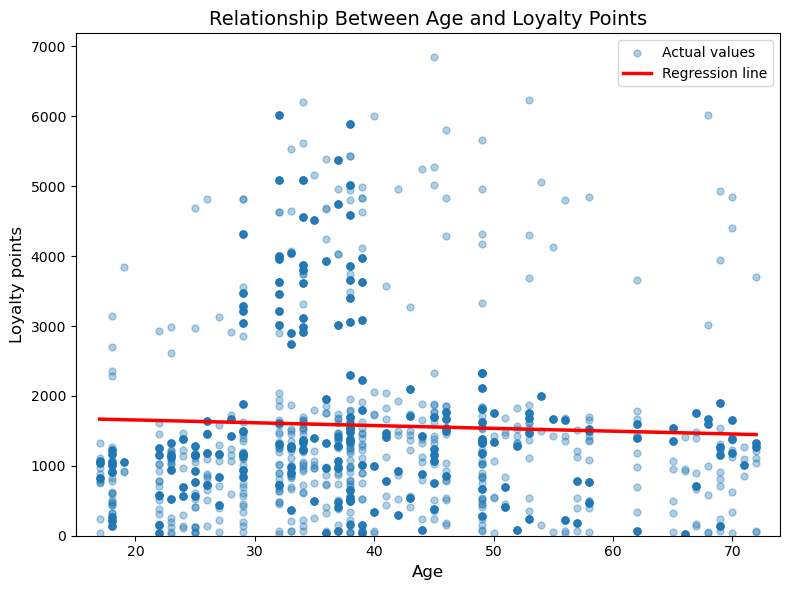

In [21]:
# Plot graph with regression line.
# Sort the regression table so the regression line is drawn correctly.
regression_table_sorted = regression_table.sort_values("age")

# Create a larger figure.
plt.figure(figsize=(8, 6))

# Plot the actual data points.
plt.scatter(
    regression_table["age"],
    regression_table["loyalty_points"],
    alpha=0.35,
    s=25,
    label="Actual values")

# Plot the regression line.
plt.plot(
    regression_table_sorted["age"],
    regression_table_sorted["predicted_loyalty_points"],
    color="red",
    linewidth=2.5,
    label="Regression line")

# Add labels and title.
plt.xlabel("Age", fontsize=12)
plt.ylabel("Loyalty points", fontsize=12)
plt.title(
    "Relationship Between Age and Loyalty Points",
    fontsize=14)

# Set appropriate axis limits.
plt.xlim(
    regression_table["age"].min() - 2,
    regression_table["age"].max() + 2)
plt.ylim(bottom=0)

# Add the legend.
plt.legend()

# Improve spacing.
plt.tight_layout()

# Display the graph.
plt.show()

**The graph supports the regression results:**

The regression line is almost flat, with only a very slight downward slope.
Loyalty points vary widely at nearly every age.
Customers of the same age can have very low or very high loyalty points.
Therefore, age does not explain customer loyalty well.

**Conclusion**

The scatterplot shows no meaningful linear relationship between age and loyalty points. The regression line has a slight negative slope, suggesting that loyalty points may decrease marginally with age, but the observations are widely dispersed. 
Together with the very low Rˆ2 of 0.002 and the p-value of 0.058, this indicates that age is not a statistically significant or practically useful predictor of loyalty points.

## 6. Observations and insights

**Linear Regression Modeling**

**5a) Spending vs. Loyalty:** Identified spending score as the strongest individual predictor (Rˆ2=0.452).
Every 1-point increase in spending score drives an average increase of ~33 loyalty points. 
Observed heteroscedasticity: variance increases at higher spending scores, revealing distinct customer sub-segments among high spenders.
 
**5b) Remuneration vs. Loyalty:** Established remuneration as a moderate, statistically significant predictor (Rˆ2 =0.380). 
Every £1,000 increase in annual income correlates with an average gain of ~34 loyalty points. Similar to spending, high-income brackets exhibit high variance, indicating income alone does not guarantee high engagement.

**5c) Age vs. Loyalty:** Concluded that age is not a statistically valid predictor of loyalty points. The Rˆ2 value is negligible (0.002), and the p-value (0.058) fails to meet the standard 5% significance threshold.

# 2. Decision Tree – Customer Loyalty Segmentation

The team wants you to use decision trees to attempt to better understand the structure found in the data. You need to grow and prune a decision tree regressor and then visualise and interpret the output.
Make sure to comment on the potential usefulness in decision-making processes and your observations regarding the model.

## Instructions
1. Prepare the data for creating your decision tree. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame with the appropriate columns.
        1. Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
        2. Specify X for the independent variables and y as the dependent variable. Therefore, df\[cols\] will be the independent variables and the column containing loyalty points the dependent variable.
        3. Explore the new DataFrame. 
2. Split the data set into a train and test sets for both X and y at a 70:30 ratio. As previously, random_state=42.
3. Create a decision tree regressor to explore the impact of other features on the loyalty points.
    1. Import the DecisionTreeRegressor class from the sklearn.tree library. 
    2. Create a variable (e.g. regressor) to store the DecisionTreeRegressor() class. (As previously, random_state=42.).
    3. Fit the regressor object to the data set with the fit() function.
    4. Remember to prune your tree using basic pruning strategies and compare the performance before and after applying the pruning strategy.
    5. Plot the final decision tree.
4. Fit a final model and interpret the output.
    1. Justify your selection of pruning strategy implemented and interpret the output.
    2. Evaluate the usefulness of the obtained result and interpret the tree and how it could be used to inform business decisions in the organisation.
5. Summarise (150–200 words) the most important business insights, anything you would like to explore further, and suggested future actions.
 
Back up your work to a safe location. This will allow you to revert to a previous state in the case of making a mistake in the code or deleting a section by mistake. (A simple way of doing this is to save or email a compressed version to yourself at frequent intervals.)


## 1. Load and prepare the data

In [22]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
# Removed plot_confusion_matrix as it's deprecated - use ConfusionMatrixDisplay instead
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt
from sklearn import tree

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [23]:
# Create your new DataFrame.

df2 = pd.read_csv("turtle_reviews_clean.csv")

df2.rename(
    columns={'spending_score (1-100)': 'spending_score'},
    inplace=True)

# View the first rows
df2.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [24]:
df2['education'].value_counts(dropna=False)

education
graduate        900
PhD             460
postgraduate    400
diploma         190
Basic            50
Name: count, dtype: int64

In [25]:
# Specify variable y: the dependent/target variable.
y = df2['loyalty_points']

# Specify X: the independent variables.
cols = [
    'gender',
    'age',
    'remuneration',
    'spending_score',
    'education',
    'product']

X = df2[cols].copy()

# Convert gender into numerical values.
X['gender'] = X['gender'].map({
    'Female': 0,
    'Male': 1})

# Convert education into ordered numerical values.
X['education'] = X['education'].map({
    'Basic': 1,
    'diploma': 2,
    'graduate': 3,
    'postgraduate': 4,
    'PhD': 5})

# Review X and y.
display(X.head())
display(y.head())

,gender,age,remuneration,spending_score,education,product
0,1,18,12.30,39,3,453
1,1,23,12.30,81,3,466
2,0,22,13.12,6,3,254
3,0,25,13.12,77,3,263
4,0,33,13.94,40,3,291


0    210
1    524
2     40
3    562
4    366
Name: loyalty_points, dtype: int64

In [26]:
y.head()

0    210
1    524
2     40
3    562
4    366
Name: loyalty_points, dtype: int64

## 2. Create train and test data sets.

In [27]:
# Split the data into test and train data.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1400, 6)
X_test: (600, 6)
y_train: (1400,)
y_test: (600,)


## 3. Create Decision tree regressor

In [28]:
# Create your decision tree regressor.

regressor = DecisionTreeRegressor(random_state=42)

# Fit the training data.
regressor.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [29]:
# Evaluate the model.

# Predict using the training data.
y_pred_train = regressor.predict(X_train)

# Predict using the test data.
y_pred_test = regressor.predict(X_test)

# Print accuracy values.
print("Training R-squared:", regressor.score(X_train, y_train))
print("Test R-squared:", regressor.score(X_test, y_test))

Training R-squared: 1.0
Test R-squared: 0.9939865106655996


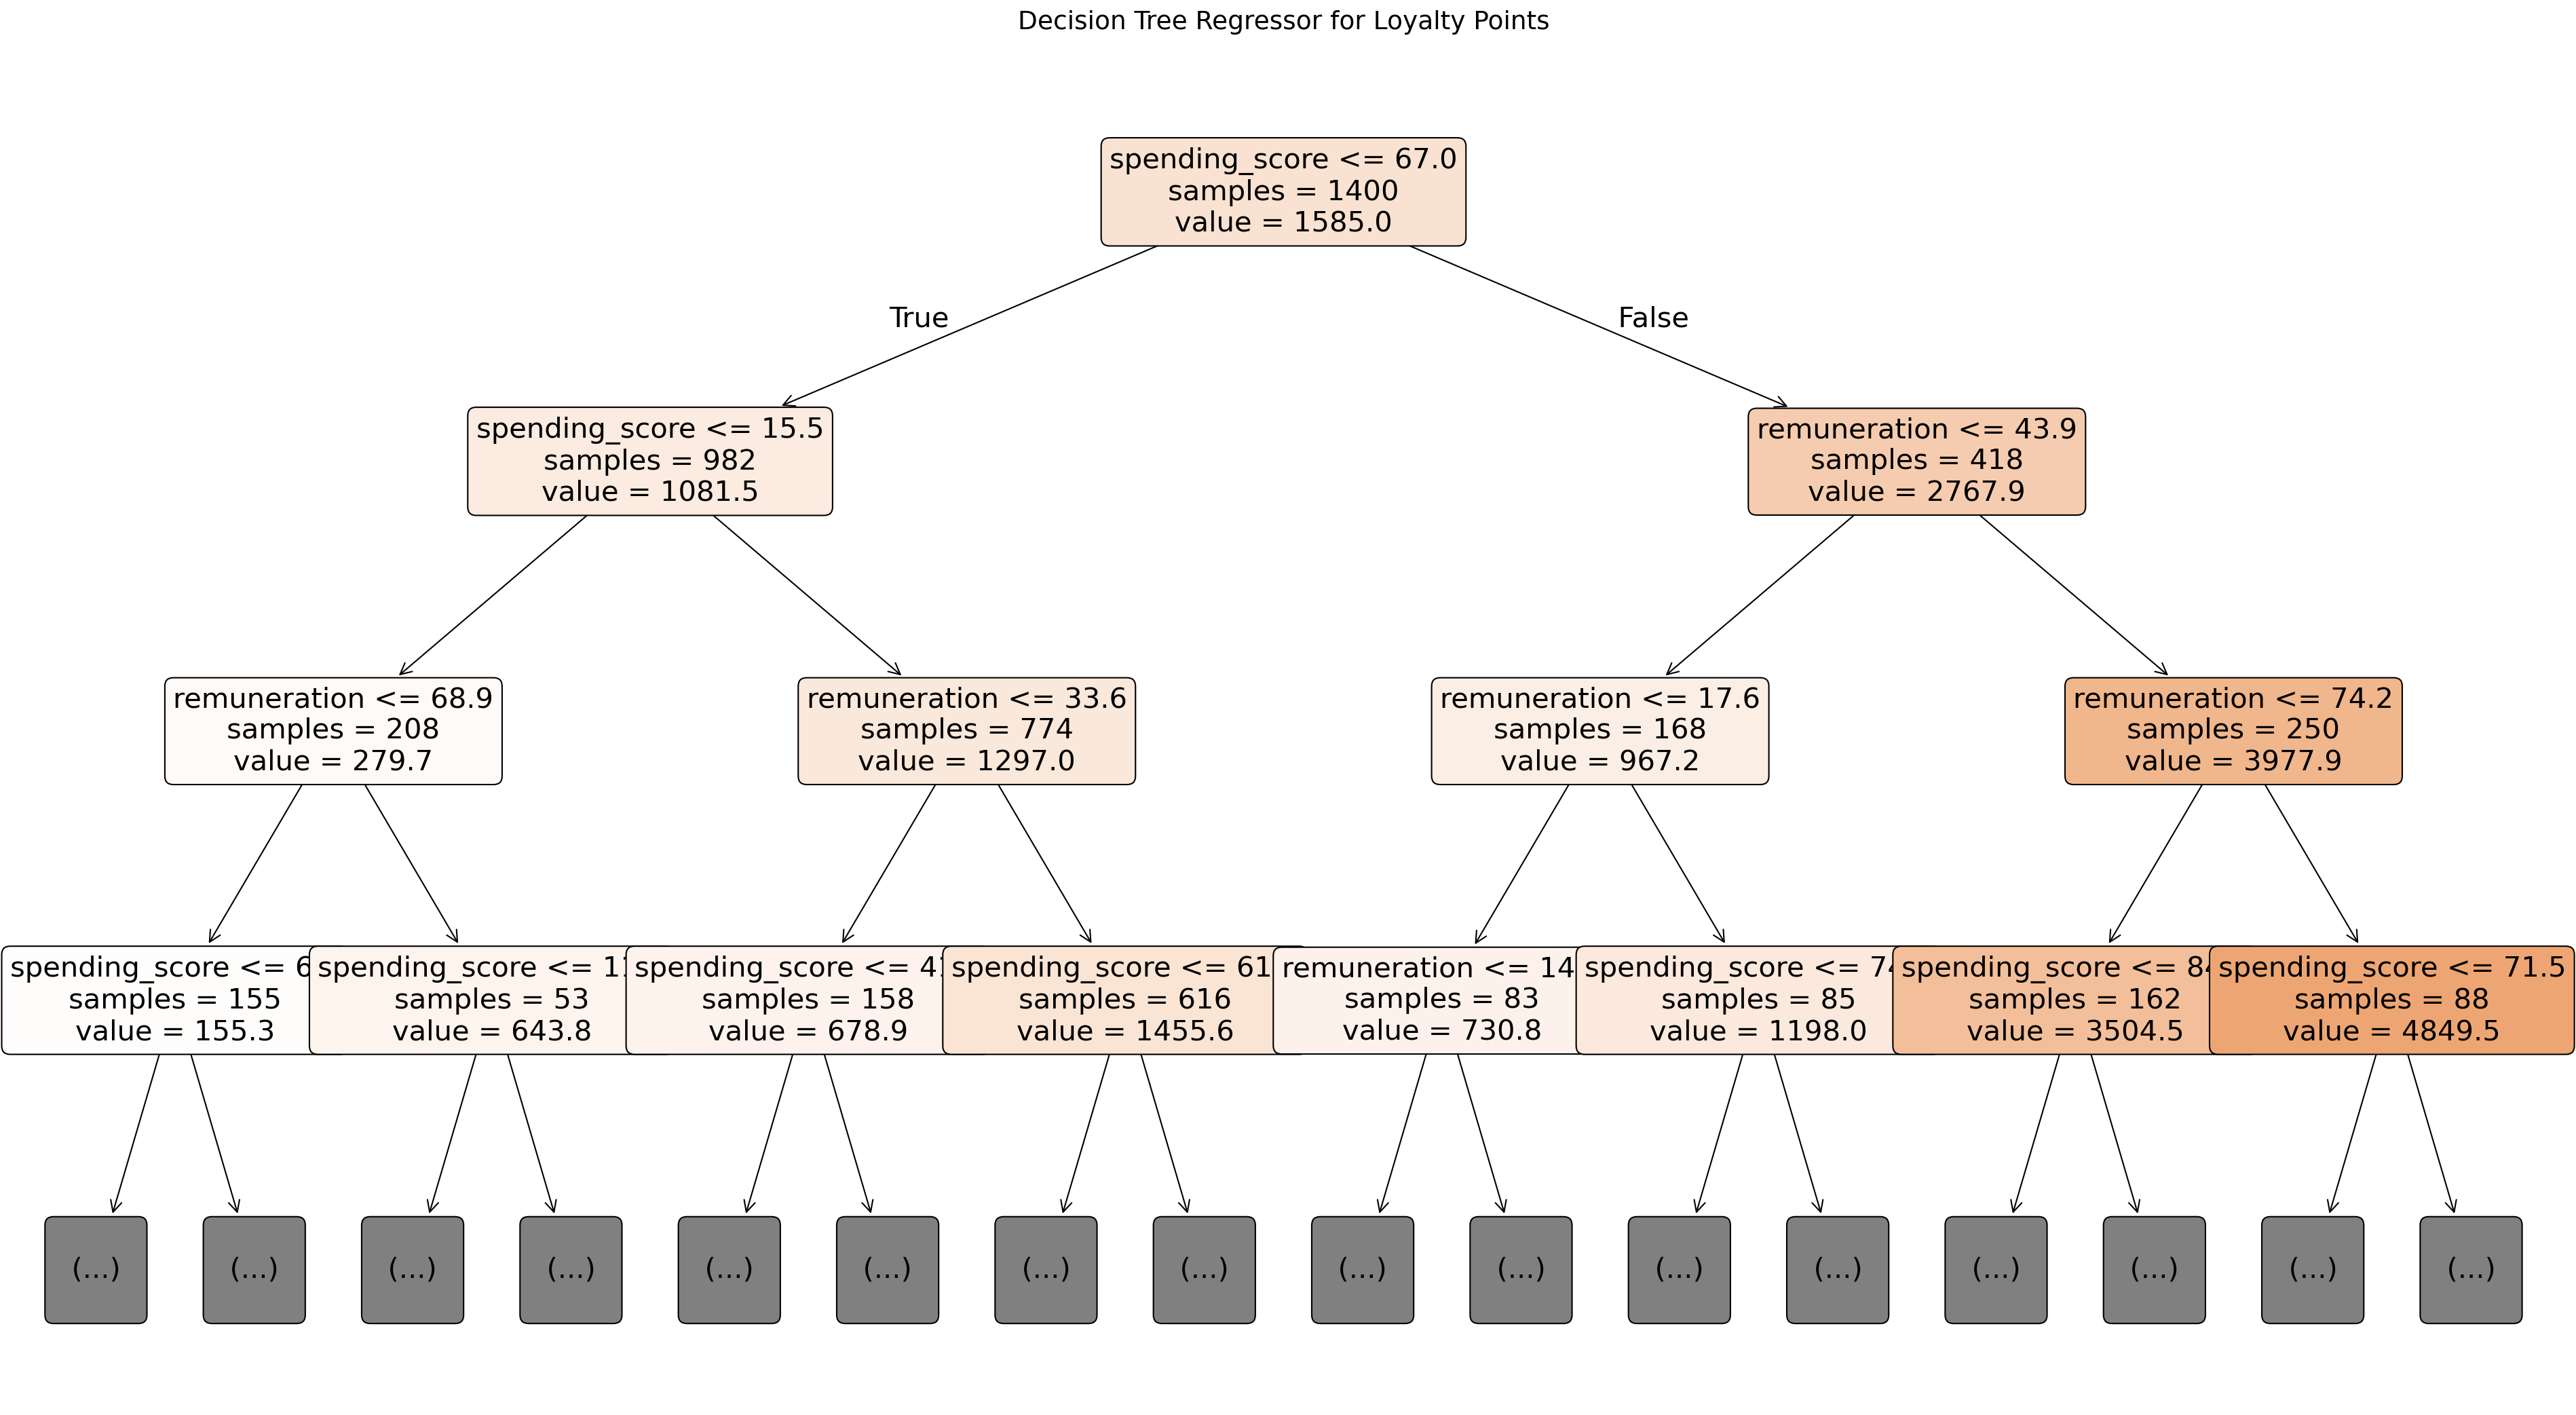

<Figure size 1500x1000 with 0 Axes>

In [30]:
# Plot the decision tree.
fig, ax = plt.subplots(figsize=(26, 14), dpi=150)

tree.plot_tree(
    regressor,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=20,
    max_depth=3,
    precision=1,
    impurity=False,
    ax=ax)

plt.title("Decision Tree Regressor for Loyalty Points", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

**Main findings**

The first and most important split is based on spending_score, suggesting that it is the strongest variable for explaining loyalty points.


**Among customers with a spending score of 67 or below:**
* Those with spending_score <= 67 have  about 1,081.5 loyalty points on average.
* Those with spending_score > 67 have much higher on average: 2,767.9 loyalty points.

**Among customers with a spending score of 67 or below:**
* Those with spending_score <= 15.5 have only about 279.7 loyalty points on average.
* Those with spending_score > 15.5 have about 1,297 loyalty points on average.


**Among customers with a spending score above 67, remuneration becomes particularly important:**
* When remuneration <= 43.9, the average is approximately 967.2 loyalty points.
* When remuneration > 43.9, the average rises sharply to approximately 3,977.9 loyalty points.

## 4. Fit and plot final model.

In [31]:
# Prune the model.
# Import the required classes and metrics
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Create the pre-pruned decision tree regressor
regressor_pruned = DecisionTreeRegressor(
    criterion='squared_error',
    max_depth=5,
    min_samples_leaf=5,
    min_samples_split=5,
    random_state=42)

# Fit the pruned model using the training data
regressor_pruned.fit(X_train, y_train)

# Make predictions.
y_pred_train_pruned = regressor_pruned.predict(X_train)
y_pred_test_pruned = regressor_pruned.predict(X_test)

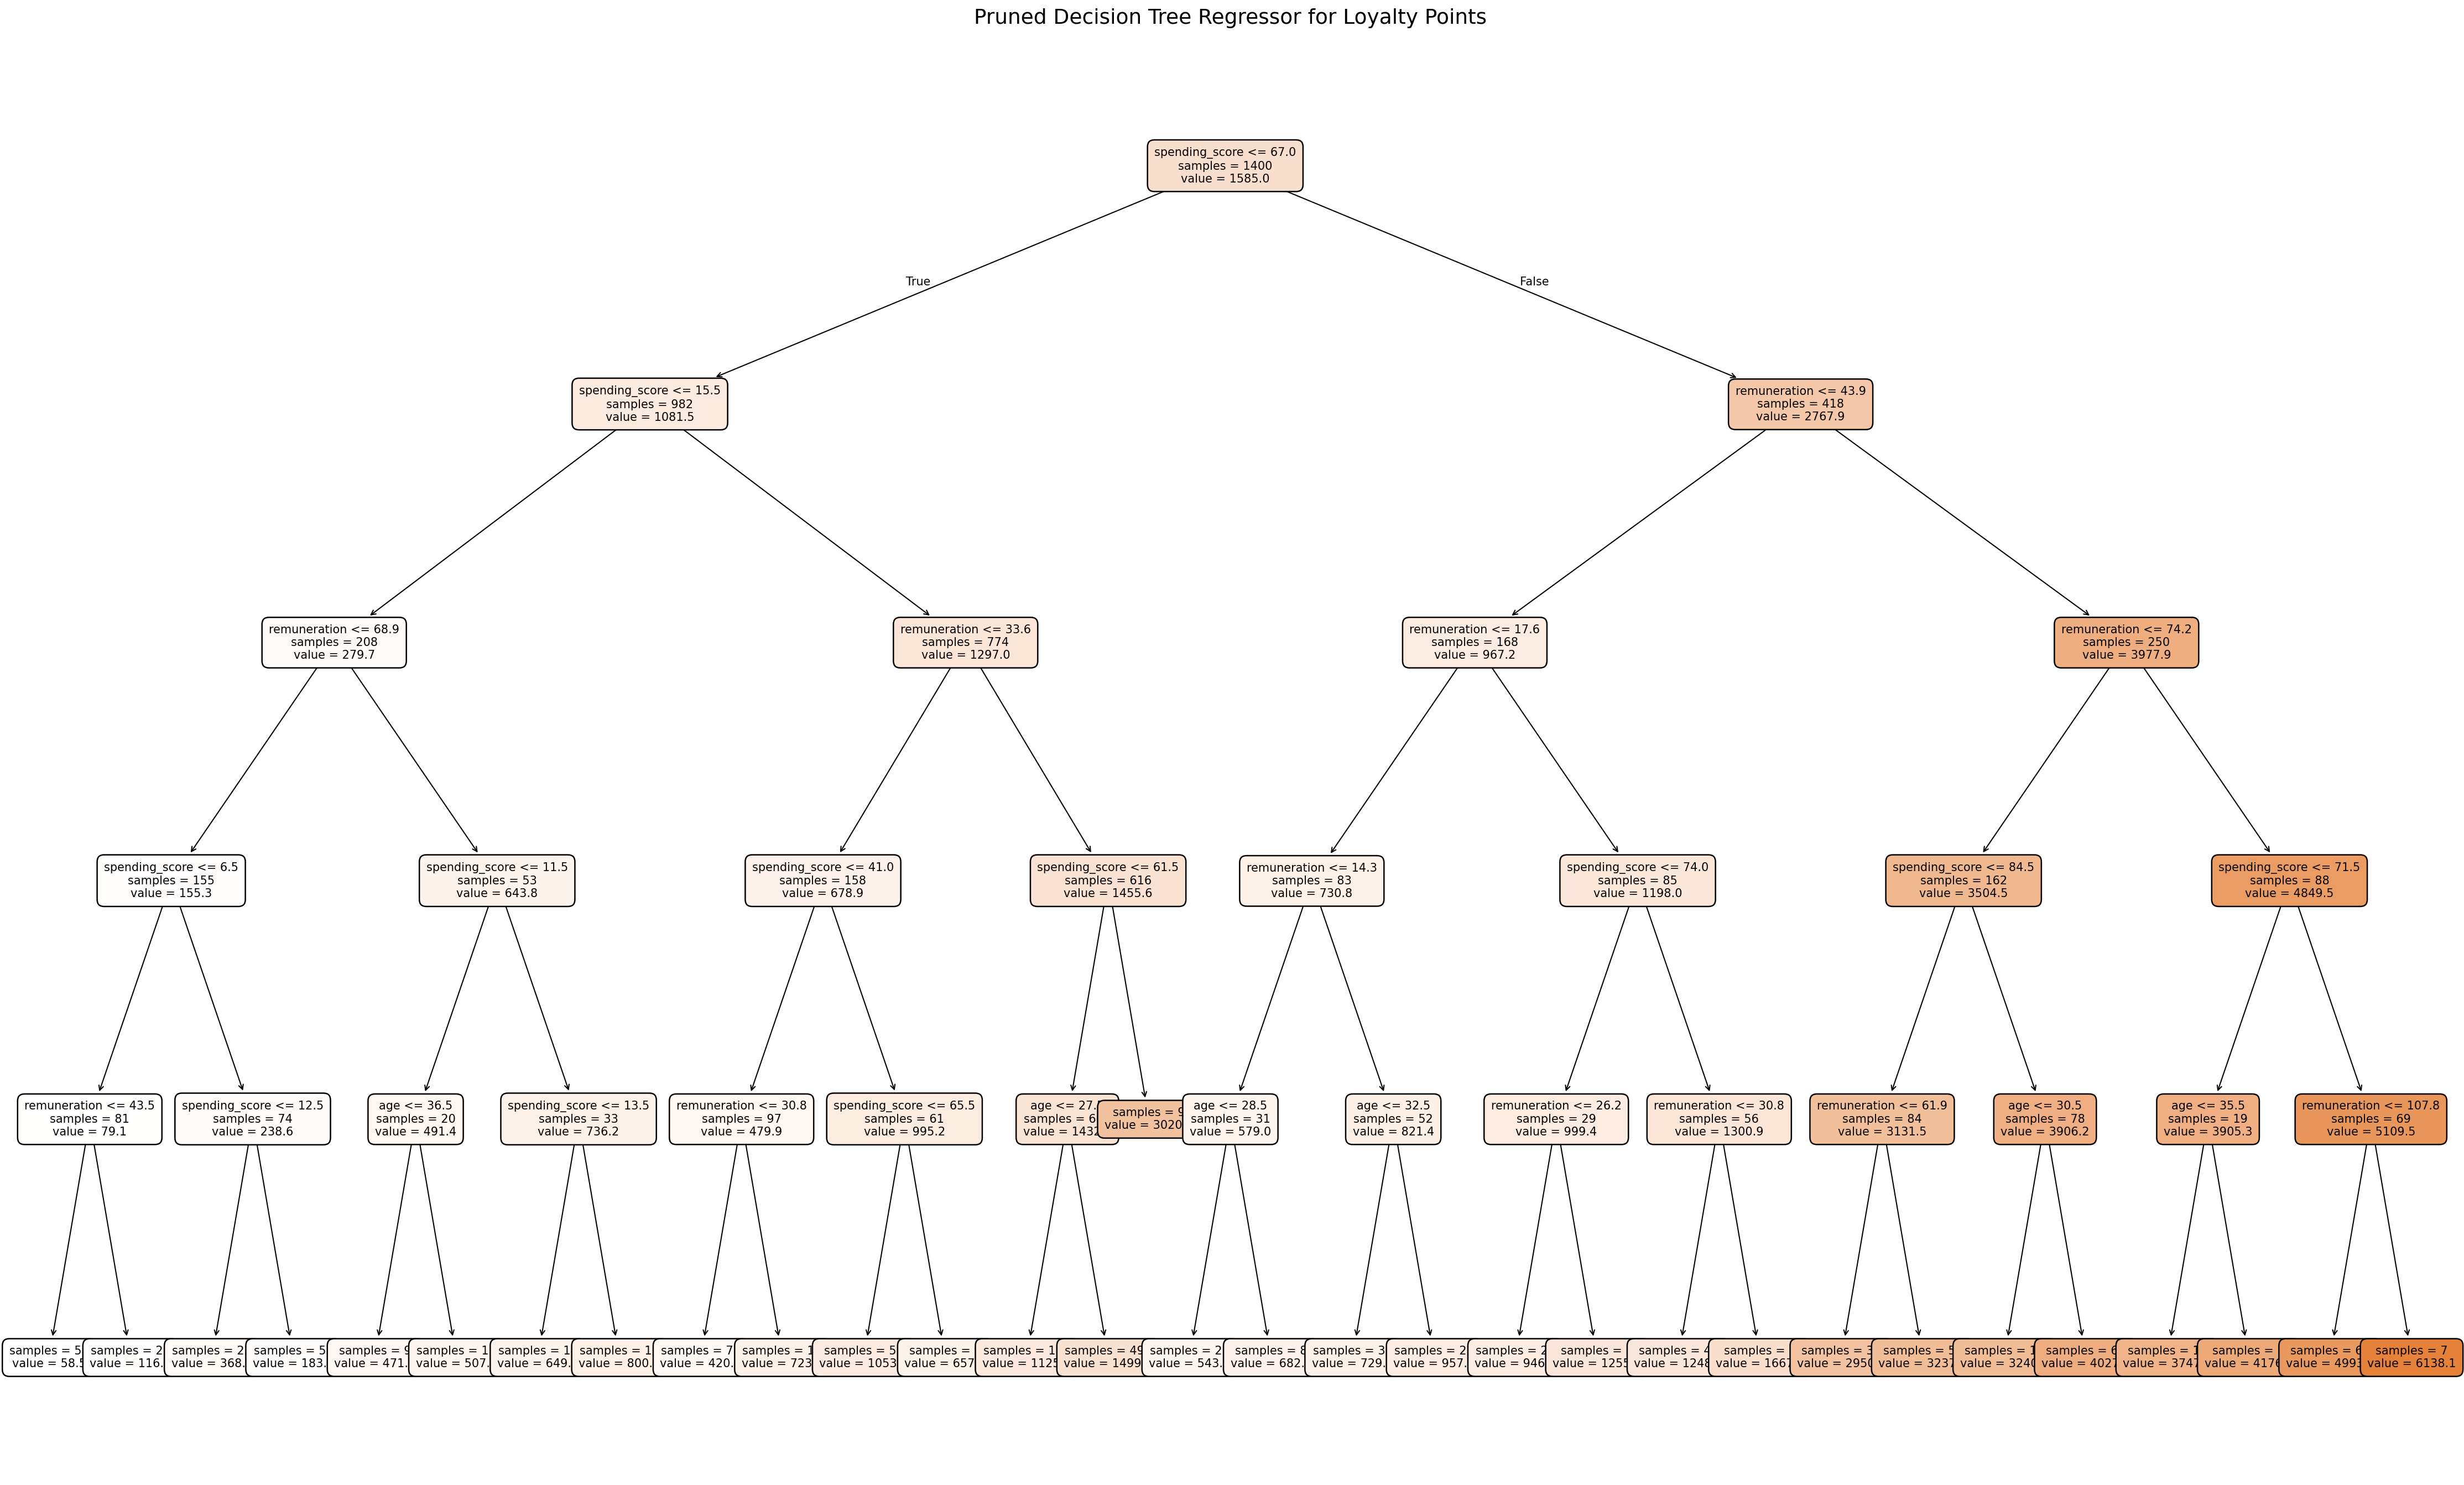

In [32]:
# Import required modules.
import matplotlib.pyplot as plt
from sklearn import tree

# Plot the pruned decision tree
fig, ax = plt.subplots(figsize=(30, 18), dpi=150)

nodes = tree.plot_tree(
    regressor_pruned,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=10,
    precision=1,
    impurity=False,
    ax=ax)

# Increase the size of the node rectangles
for node in nodes:
    box = node.get_bbox_patch()

    if box is not None:
        box.set_boxstyle("round,pad=0.6")
        box.set_linewidth(1.2)

plt.title(
    "Pruned Decision Tree Regressor for Loyalty Points",
    fontsize=18,
    pad=20)

plt.tight_layout()
plt.show()

## 5. Discuss: Insights and observations

# Interpret model and note observations.

The results show that loyalty accumulation follows **threshold-based behaviour**, rather than one uniform relationship across all customers. Customers with spending scores above 67 generally hold substantially more loyalty points. However, remuneration further separates these customers: higher-remuneration customers accumulate nearly 4,000 points on average, while similarly high-scoring but lower-remuneration customers average fewer than 1,000.

This identifies a potentially important **high-spending but low-loyalty segment**, suggesting that spending potential does not always translate into programme engagement. Age, gender, education, and product did not drive the upper-level tree splits and appear less influential for initial segmentation.

# 3. K-Means Clustering – Customer Segmentation

The marketing department also wants to better understand the usefulness of remuneration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `remuneration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the remuneration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhouette methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [33]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [34]:
# Load the CSV file(s) as df3.

df3 = pd.read_csv("turtle_reviews_clean.csv")

# View DataFrame.
df3.head()
print(df3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration            2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   product                 2000 non-null   int64  
 7   review                  2000 non-null   object 
 8   summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB
None


In [35]:
# Drop unnecessary columns.
df3 = df3[['remuneration', 'spending_score (1-100)']].copy()

# View DataFrame.
df3

,remuneration,spending_score (1-100)
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40
...,...,...
1995,84.46,69
1996,92.66,8
1997,92.66,91
1998,98.40,16


In [36]:
# Explore the data.
# Determine the number of null values.
df3.isnull().sum()

remuneration              0
spending_score (1-100)    0
dtype: int64

In [37]:
# Descriptive statistics.
df3.describe()

,remuneration,spending_score (1-100)
count,2000.000000,2000.000000
mean,48.079060,50.000000
std,23.123984,26.094702
min,12.300000,1.000000
25%,30.340000,32.000000
50%,47.150000,50.000000
75%,63.960000,73.000000
max,112.340000,99.000000


## 2. Plot

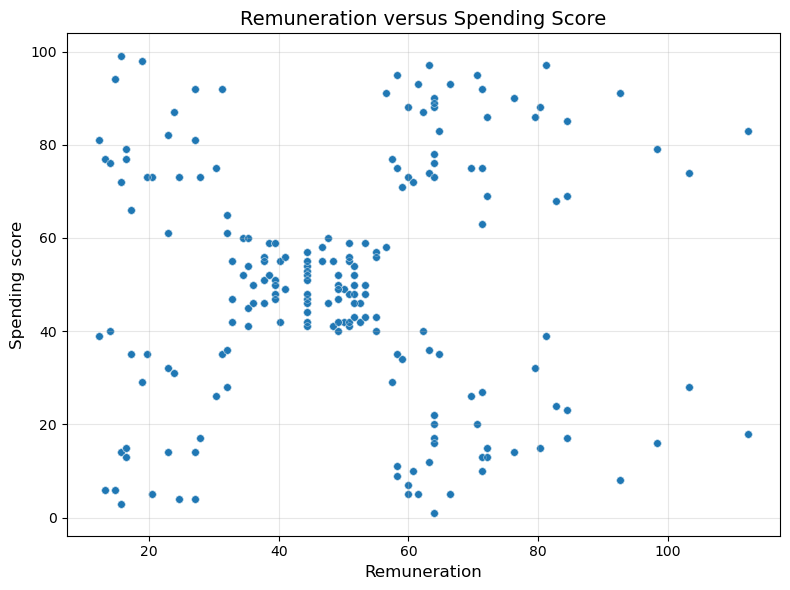

In [38]:
# Create a scatterplot of remuneration versus spending score.
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df3,
    x='remuneration',
    y='spending_score (1-100)',
    alpha=0.45,
    s=30)

plt.xlabel('Remuneration', fontsize=12)
plt.ylabel('Spending score', fontsize=12)
plt.title('Remuneration versus Spending Score', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

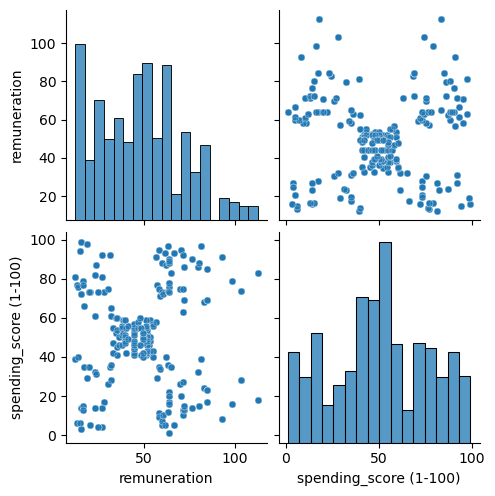

,remuneration,spending_score (1-100)
remuneration,1.000000,0.005612
spending_score (1-100),0.005612,1.000000


In [39]:
# Create a pairplot with Seaborn.
sns.pairplot(
    df3,
    diag_kind='hist',
    plot_kws={'alpha': 0.45, 's': 25})

plt.show()

df3.corr()

## 3. Elbow and silhouette methods

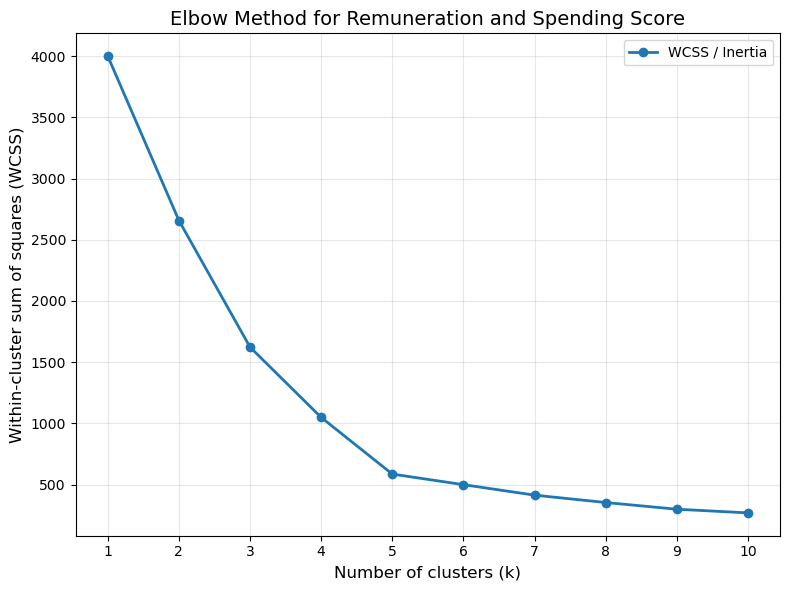

,Number of clusters,WCSS
0,1,4000.000000
1,2,2657.345921
2,3,1622.668783
3,4,1048.678104
4,5,585.566140
5,6,499.154921
6,7,413.493359
7,8,353.334426
8,9,298.580796
9,10,268.612743


In [40]:
# Determine the number of clusters: Elbow method.

# Select only the variables used for clustering.
X = df3[['remuneration', 'spending_score (1-100)']]

# Standardise the variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Define the range of possible cluster numbers.
k_values = range(1, 11)

# Create an empty list to store WCSS values.
wcss = []

# Calculate WCSS for each number of clusters.
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42)

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the Elbow method.
plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    wcss,
    marker='o',
    linewidth=2,
    label='WCSS / Inertia')

plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Within-cluster sum of squares (WCSS)', fontsize=12)
plt.title(
    'Elbow Method for Remuneration and Spending Score',
    fontsize=14)

plt.xticks(range(1, 11))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
###########################################################
# Display the WCSS value for each number of clusters.
elbow_results = pd.DataFrame({
    'Number of clusters': list(k_values),
    'WCSS': wcss})

elbow_results

Optimal number of clusters: 5
Highest silhouette score: 0.582


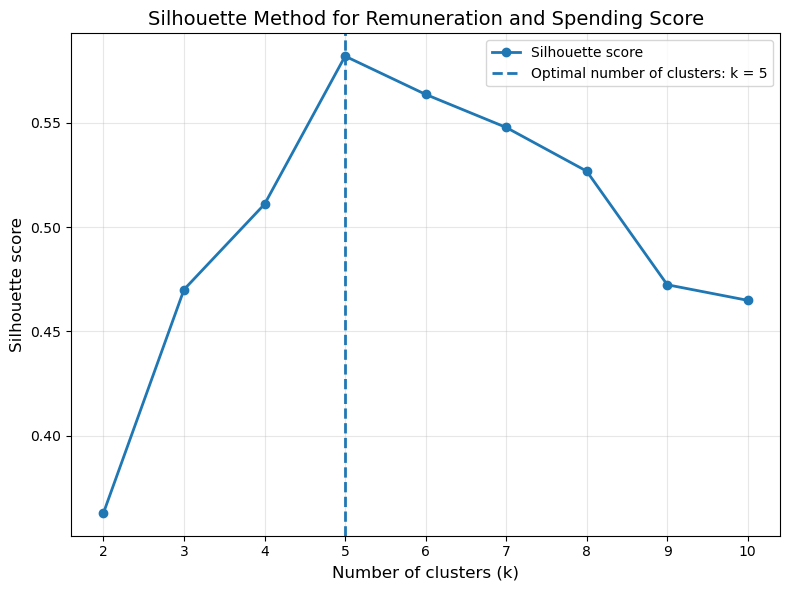

In [41]:
# Determine the number of clusters: Silhouette method.

# Select the variables used for clustering.
X = df3[['remuneration', 'spending_score (1-100)']]

# Standardise the variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Test possible cluster numbers from 2 to 10.
# Silhouette score cannot be calculated for only one cluster.
k_values = range(2, 11)

# Create an empty list to store the silhouette scores.
silhouette_scores = []

# Calculate the silhouette score for each value of k.
for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42)

    cluster_labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        cluster_labels)

    silhouette_scores.append(score)

# Automatically identify the highest silhouette score.
optimal_k = list(k_values)[np.argmax(silhouette_scores)]
highest_score = max(silhouette_scores)

print('Optimal number of clusters:', optimal_k)
print('Highest silhouette score:', round(highest_score, 4))

# Plot the Silhouette method.
plt.figure(figsize=(8, 6))

plt.plot(
    k_values,
    silhouette_scores,
    marker='o',
    linewidth=2,
    label='Silhouette score')

# Highlight the result identified by the calculation.
plt.axvline(
    x=optimal_k,
    linestyle='--',
    linewidth=2,
    label=f'Optimal number of clusters: k = {optimal_k}')

plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Silhouette score', fontsize=12)
plt.title(
    'Silhouette Method for Remuneration and Spending Score',
    fontsize=14)

plt.xticks(range(2, 11))
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Evaluate k-means model at different values of *k*

In [42]:
# Evaluate the model when k=4, k=6, k=7.

# Select the variables used for clustering.
X = df3[['remuneration', 'spending_score (1-100)']].copy()

# Standardise the variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Values of k to compare.
k_values_to_test = [4, 5, 6, 7]

# Store the evaluation results and fitted models.
comparison_results = []
kmeans_models = {}

for k in k_values_to_test:
    
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        random_state=42)

    cluster_labels = kmeans.fit_predict(X_scaled)

    comparison_results.append({
        'Number of clusters': k,
        'WCSS': kmeans.inertia_,
        'Silhouette score': silhouette_score(
            X_scaled,
            cluster_labels)})

    kmeans_models[k] = {
        'model': kmeans,
        'labels': cluster_labels}

# Display the evaluation results.
comparison_results = pd.DataFrame(comparison_results)

comparison_results.round({
    'WCSS': 2,
    'Silhouette score': 4})

,Number of clusters,WCSS,Silhouette score
0,4,1048.68,0.5110
1,5,585.57,0.5820
2,6,499.15,0.5636
3,7,413.49,0.5478


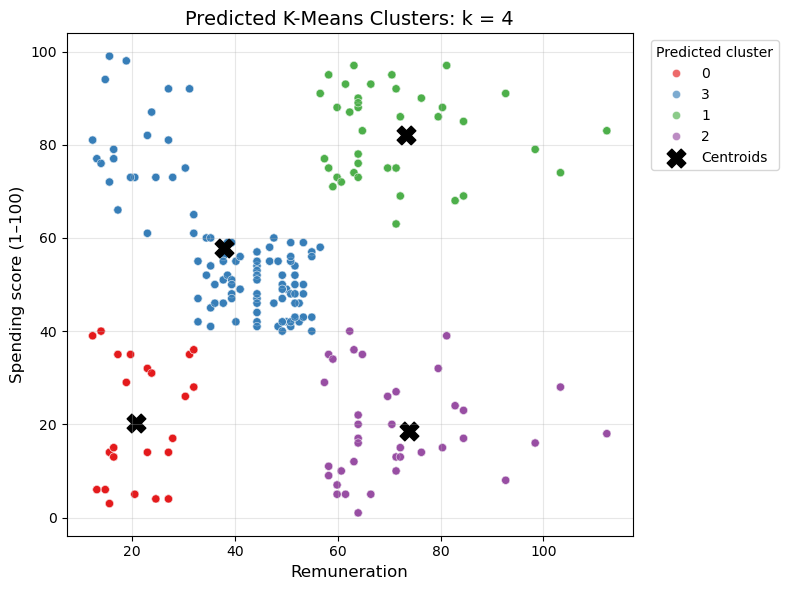

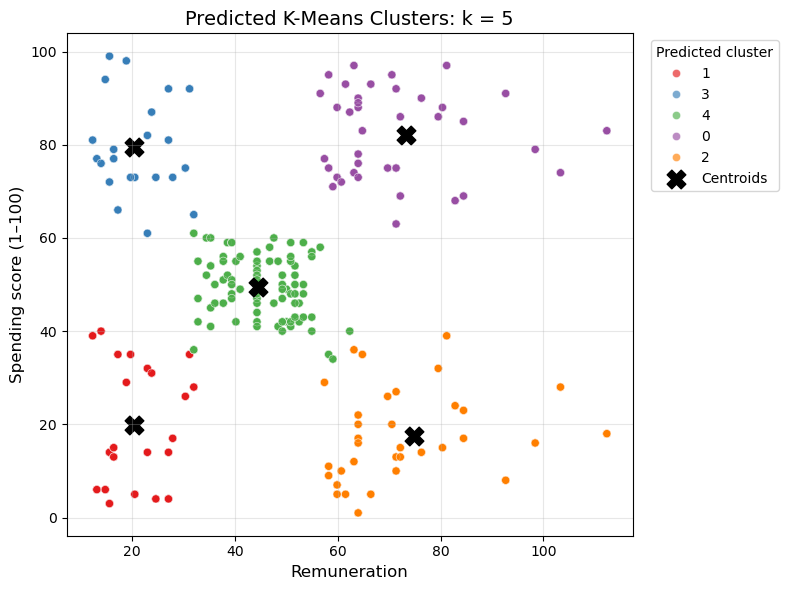

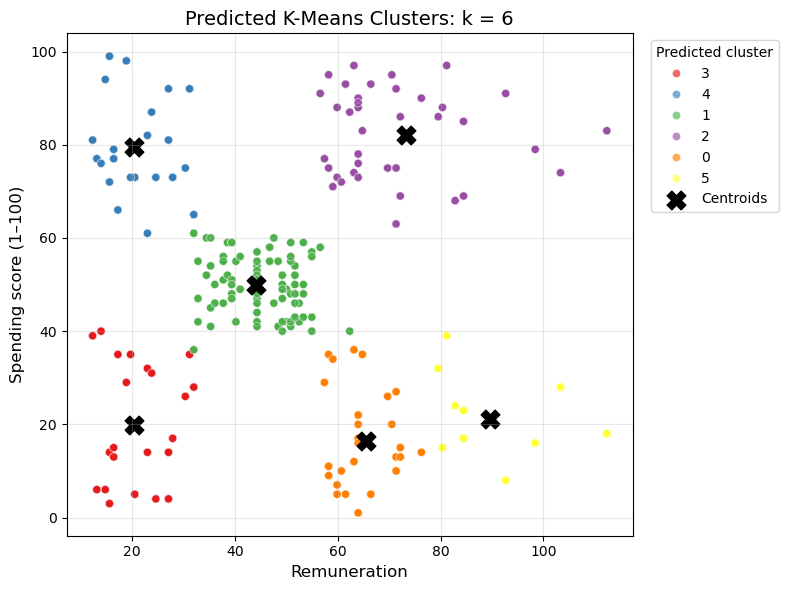

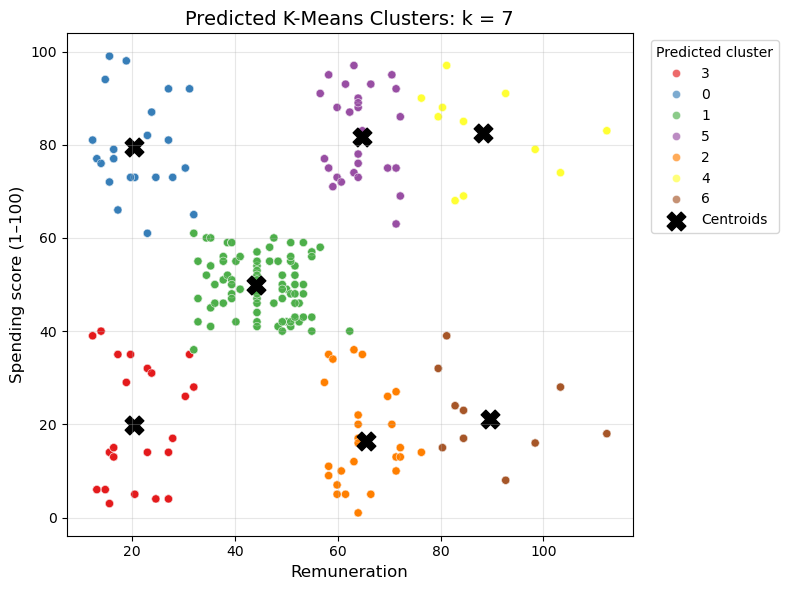

In [43]:
# Plot the predicted k-means clusters for each value of k.

for k in k_values_to_test:

    # Retrieve the fitted model and predicted labels.
    kmeans = kmeans_models[k]['model']
    cluster_labels = kmeans_models[k]['labels']

    # Create a DataFrame for plotting.
    plot_data = X.copy()
    plot_data['Cluster'] = cluster_labels.astype(str)

    # Convert the centroids back to the original measurement scale.
    centroids = scaler.inverse_transform(
        kmeans.cluster_centers_)

    # Create the scatterplot.
    plt.figure(figsize=(8, 6))

    sns.scatterplot(
        data=plot_data,
        x='remuneration',
        y='spending_score (1-100)',
        hue='Cluster',
        palette='Set1',
        alpha=0.65,
        s=35)

    # Plot the cluster centroids.
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker='X',
        s=180,
        color='black',
        label='Centroids')

    plt.xlabel('Remuneration', fontsize=12)
    plt.ylabel('Spending score (1–100)', fontsize=12)

    plt.title(
        f'Predicted K-Means Clusters: k = {k}',
        fontsize=14)

    plt.legend(
        title='Predicted cluster',
        bbox_to_anchor=(1.02, 1),
        loc='upper left')

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 5. Fit final model and justify your choice

In [44]:
# Apply the final model.

# Select the variables used for clustering.
X = df3[['remuneration', 'spending_score (1-100)']].copy()

# Standardise the variables.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit the final k-means model using five clusters.
final_kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42)

# Predict the cluster for each observation.
final_clusters = final_kmeans.fit_predict(X_scaled)

# Add the predicted clusters to the DataFrame.
df3['K-Means Predicted'] = final_clusters

# View the DataFrame.
df3.head()

,remuneration,spending_score (1-100),K-Means Predicted
0,12.30,39,1
1,12.30,81,3
2,13.12,6,1
3,13.12,77,3
4,13.94,40,1


In [45]:
# Check the number of observations per predicted class.
# Check the number of observations per predicted class.
cluster_sizes = (
    df3['K-Means Predicted']
    .value_counts()
    .sort_index())

cluster_sizes

K-Means Predicted
0    356
1    271
2    330
3    269
4    774
Name: count, dtype: int64

## 6. Plot and interpret the clusters

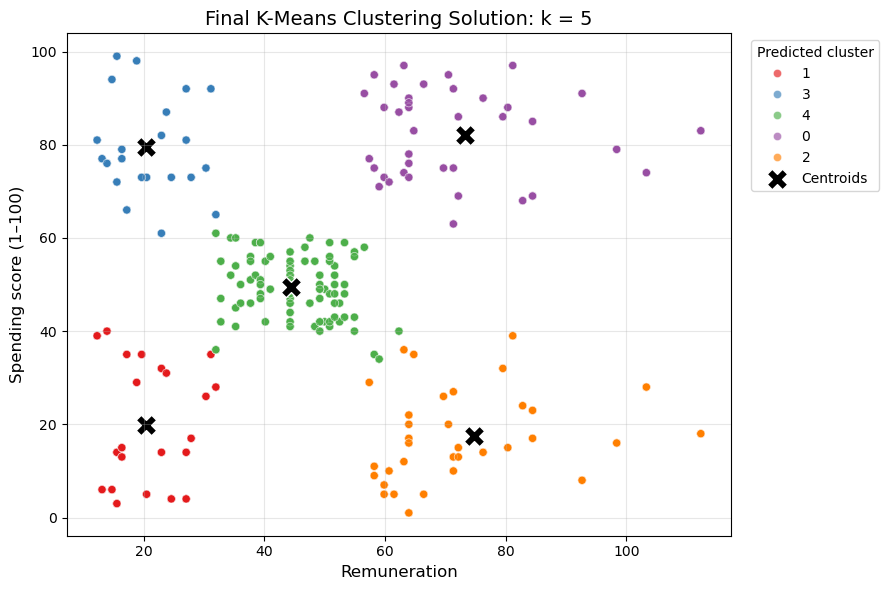

In [46]:
# Visualise the final selected k-means model.

# Convert the cluster centres back to the original scale.
final_centroids = scaler.inverse_transform(
    final_kmeans.cluster_centers_)

# Create a separate column for clear legend labels.
df3['Cluster'] = df3['K-Means Predicted'].astype(str)

# Plot the five final clusters.
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df3,
    x='remuneration',
    y='spending_score (1-100)',
    hue='Cluster',
    palette='Set1',
    alpha=0.65,
    s=35)

# Add the cluster centres.
plt.scatter(
    final_centroids[:, 0],
    final_centroids[:, 1],
    marker='X',
    s=220,
    color='black',
    edgecolor='white',
    linewidth=1,
    label='Centroids')

plt.xlabel('Remuneration', fontsize=12)
plt.ylabel('Spending score (1–100)', fontsize=12)

plt.title(
    'Final K-Means Clustering Solution: k = 5',
    fontsize=14)

plt.legend(
    title='Predicted cluster',
    bbox_to_anchor=(1.02, 1),
    loc='upper left')

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Discuss: Insights and observations

**Both methods point to the same result: five clusters.**

The Elbow method shows a sharp decrease in WCSS up to k = 5. After five clusters, the curve becomes much flatter, meaning that adding more clusters produces only a small improvement.

The Silhouette method gives its highest score at k = 5, meaning that five clusters provide the best balance between:
similarity of observations within each cluster;
separation between different clusters.

Therefore, the two methods provide consistent evidence that:

**The optimal number of clusters for the remuneration and spending-score data is five.**

This does not mean that five is mathematically the only possible answer, but it is **the best-supported choice among the tested values.**
_________________________________________________________________________________________________
**Evaluation of each value**

**k = 4**
The silhouette score is approximately **0.511**, which indicates a reasonable cluster structure, but it is lower than the score for five clusters.
The WCSS is also relatively high at approximately 1048.68. 
Visually, four clusters are not sufficient to represent all the apparent customer groups. In particular, some low-remuneration customers with different spending behaviours are likely to be combined into one broad cluster.
Therefore, k = 4 appears to **underfit the data**.

**k = 5**
The silhouette score reaches its highest value of approximately **0.582**. This means that the observations are more cohesive within their own clusters and better separated from other clusters than under the other tested solutions.

**k = 6**
The WCSS decreases to approximately 499.15, but this is a much smaller improvement than the reduction obtained when moving from four to five clusters.
The silhouette score also falls from approximately 0.582 to **0.564**. This suggests that introducing a sixth cluster does not improve the overall separation of the groups.

**k = 7**
The WCSS decreases further to approximately **413.49**, which is expected because WCSS always decreases when more clusters are introduced.
However, the silhouette score falls again to approximately 0.548. The seven-cluster model subdivides existing groups into increasingly small segments without producing better-separated clusters. Therefore, k = 7 appears to **over-segment the data**.

**Final conclusion**
Four clusters provide a simpler model but combine customer groups that appear to have different spending behaviours. Six and seven clusters reduce WCSS, but their silhouette scores are lower, indicating that the additional clusters do not improve separation and mainly divide existing groups into smaller subgroups. Five clusters produce the highest silhouette score and correspond to the elbow in the WCSS curve. Therefore, k = 5 provides the best balance between cluster quality, model simplicity, and business interpretability.

# 4. NLP – Customer Review Analysis
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. Therefore, the marketing department asked you to identify the 15 most common words used in online product reviews. They also want to have a list of the top 20 positive and negative reviews received from the website. Therefore, you need to apply NLP on the data set.

## Instructions
1. Load and explore the data. 
    1. Sense-check the DataFrame.
    2. You only need to retain the `review` and `summary` columns.
    3. Determine if there are any missing values.
2. Prepare the data for NLP
    1. Change to lower case and join the elements in each of the columns respectively (`review` and `summary`).
    2. Replace punctuation in each of the columns respectively (`review` and `summary`).
    3. Drop duplicates in both columns (`review` and `summary`).
3. Tokenise and create wordclouds for the respective columns (separately).
    1. Create a copy of the DataFrame.
    2. Apply tokenisation on both columns.
    3. Create and plot a wordcloud image.
4. Frequency distribution and polarity.
    1. Create frequency distribution.
    2. Remove alphanumeric characters and stopwords.
    3. Create wordcloud without stopwords.
    4. Identify 15 most common words and polarity.
5. Review polarity and sentiment.
    1. Plot histograms of polarity (use 15 bins) for both columns.
    2. Review the sentiment scores for the respective columns.
6. Identify and print the top 20 positive and negative reviews and summaries respectively.
7. Include your insights and observations.

## 1. Load and explore the data

In [47]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

# nltk.download ('punkt').
# nltk.download ('stopwords').

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [48]:
# Load the data set as df4.
df4 = pd.read_csv('turtle_reviews_clean.csv')

# View DataFrame.
df4.head()

,gender,age,remuneration,spending_score (1-100),loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


In [49]:
# Explore data set.

# View the dimensions of the DataFrame.
print("DataFrame dimensions:", df4.shape)

# View column names and data types.
df4.info()

# Check for missing values.
print("\nMissing values:")
print(df4.isnull().sum())

# Check for duplicated rows.
print("\nNumber of duplicated rows:", df4.duplicated().sum())

# View descriptive statistics.
display(df4.describe(include='all'))

DataFrame dimensions: (2000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration            2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   product                 2000 non-null   int64  
 7   review                  2000 non-null   object 
 8   summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(4)
memory usage: 140.8+ KB

Missing values:
gender                    0
age                       0
remuneration              0
spending_score (1-100)    0
loyalty_points            0
education                 0
product                   0
re

,gender,age,remuneration,spending_score (1-100),loyalty_points,education,product,review,summary
count,2000,2000.000000,2000.000000,2000.000000,2000.000000,2000,2000.000000,2000,2000
unique,2,NaN,NaN,NaN,NaN,5,NaN,1980,1432
top,Female,NaN,NaN,NaN,NaN,graduate,NaN,love it,Five Stars
freq,1120,NaN,NaN,NaN,NaN,900,NaN,5,378
mean,NaN,39.495000,48.079060,50.000000,1578.032000,NaN,4320.521500,NaN,NaN
std,NaN,13.573212,23.123984,26.094702,1283.239705,NaN,3148.938839,NaN,NaN
min,NaN,17.000000,12.300000,1.000000,25.000000,NaN,107.000000,NaN,NaN
25%,NaN,29.000000,30.340000,32.000000,772.000000,NaN,1589.250000,NaN,NaN
50%,NaN,38.000000,47.150000,50.000000,1276.000000,NaN,3624.000000,NaN,NaN
75%,NaN,49.000000,63.960000,73.000000,1751.250000,NaN,6654.000000,NaN,NaN


In [50]:
# Keep necessary columns. Drop unnecessary columns.
df4 = df4[['review', 'summary']].copy()

# View the updated DataFrame.
df4.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [51]:
# Determine if there are any missing values.
df4.isnull().sum()

review     0
summary    0
dtype: int64

## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [52]:
# Review: Change all to lower case and join with a space.
review = ' '.join(df4['review'].str.lower())

# View output.
review[:500]

"when it comes to a dm's screen, the space on the screen itself is at an absolute premium. the fact that 50% of this space is wasted on art (and not terribly informative or needed art as well) makes it completely useless. the only reason that i gave it 2 stars and not 1 was that, technically speaking, it can at least still stand up to block your notes and dice rolls. other than that, it drops the ball completely. an open letter to galeforce9*:\n\nyour unpainted miniatures are very not bad. your spe"

In [53]:
# Summary: Change all to lower case and join with a space.
summary = ' '.join(df4['summary'].str.lower())

# View output.
summary[:500]

"the fact that 50% of this space is wasted on art (and not terribly informative or needed art ... another worthless dungeon master's screen from galeforce9 pretty, but also pretty useless five stars money trap five stars best gm screen ever five stars great but could be even better another missed opportunity.  not a value add to the product line. five stars love the map! not a general dm screen very weak game fell completely flat... five stars good book buckley was a card mommer very advanced, bu"

### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [54]:
# Import the string library.
import string

# Replace all the punctuations in review column.
review = review.translate(str.maketrans('', '', string.punctuation))

# View output.
review[:500]

'when it comes to a dms screen the space on the screen itself is at an absolute premium the fact that 50 of this space is wasted on art and not terribly informative or needed art as well makes it completely useless the only reason that i gave it 2 stars and not 1 was that technically speaking it can at least still stand up to block your notes and dice rolls other than that it drops the ball completely an open letter to galeforce9\n\nyour unpainted miniatures are very not bad your spell cards are gr'

In [55]:
# Replace all the puncuations in summary column.
summary = summary.translate(str.maketrans('', '', string.punctuation))

# View output.
summary[:500]

'the fact that 50 of this space is wasted on art and not terribly informative or needed art  another worthless dungeon masters screen from galeforce9 pretty but also pretty useless five stars money trap five stars best gm screen ever five stars great but could be even better another missed opportunity  not a value add to the product line five stars love the map not a general dm screen very weak game fell completely flat five stars good book buckley was a card mommer very advanced but as good as i'

### 2c) Drop duplicates in both columns

In [56]:
# Drop duplicates in both columns.
df4 = df4.drop_duplicates(subset=['review', 'summary']).reset_index(drop=True)

# View DataFrame.
df4.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


## 3. Tokenise and create wordclouds

In [57]:
# Create new DataFrame (copy DataFrame).
df4_nlp = df4.copy()

# View DataFrame.
df4_nlp.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [58]:
# Import the tokenizer.
import nltk
from nltk.tokenize import word_tokenize

# Download the required tokenizer data.
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

# Apply tokenisation to both columns.
df4_nlp['review_tokens'] = df4_nlp['review'].apply(
    lambda text: word_tokenize(text.lower()))

df4_nlp['summary_tokens'] = df4_nlp['summary'].apply(
    lambda text: word_tokenize(text.lower()))

# View DataFrame.
df4_nlp.head()

,review,summary,review_tokens,summary_tokens
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...,"[when, it, comes, to, a, dm, 's, screen, ,, th...","[the, fact, that, 50, %, of, this, space, is, ..."
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...,"[an, open, letter, to, galeforce9, *, :, your,...","[another, worthless, dungeon, master, 's, scre..."
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless","[nice, art, ,, nice, printing, ., why, two, pa...","[pretty, ,, but, also, pretty, useless]"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars,"[amazing, buy, !, bought, it, as, a, gift, for...","[five, stars]"
4,As my review of GF9's previous screens these w...,Money trap,"[as, my, review, of, gf9, 's, previous, screen...","[money, trap]"


In [59]:
# Review: Create a word cloud.
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Join all tokenised review words into one text string.
review_text = ' '.join([' '.join(tokens) for tokens in df4_nlp['review_tokens']])

# Create the word cloud.
review_wc = WordCloud(width=800, height=400, background_color='white').generate(review_text)

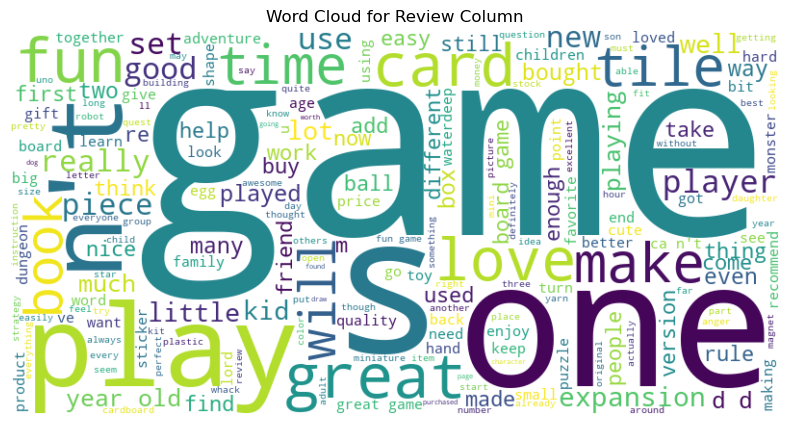

In [60]:
# Review: Plot the WordCloud image.
plt.figure(figsize=(10, 5))
plt.imshow(review_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Review Column')
plt.show()

In [61]:
# Summary: Create a word cloud.
# Join all tokenised summary words into one text string.
summary_text = ' '.join(
    [' '.join(tokens) for tokens in df4_nlp['summary_tokens']])

# Create the word cloud.
summary_wc = WordCloud(
    width=800,
    height=400,
    background_color='white').generate(summary_text)

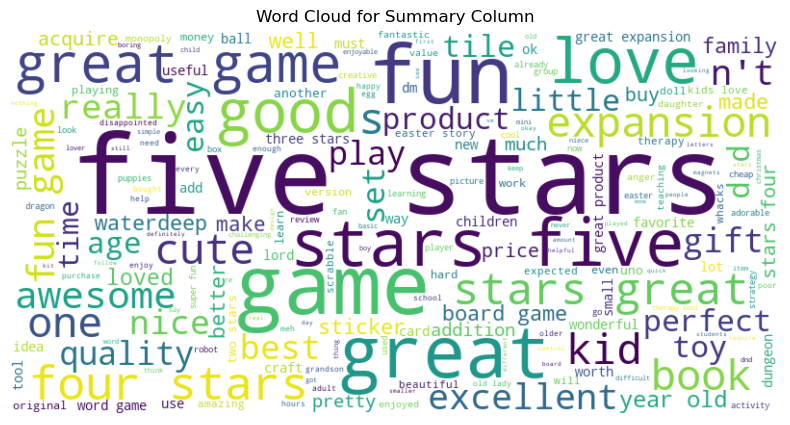

In [62]:
# Summary: Plot the WordCloud image.
plt.figure(figsize=(10, 5))
plt.imshow(summary_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Summary Column')
plt.show()

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [63]:
# Determine the frequency distribution.
review_freq_dist = FreqDist(review_text.split())
summary_freq_dist = FreqDist(summary_text.split())

### 4b) Remove alphanumeric characters and stopwords

In [64]:
# Delete all the alpanum.
review_filtered = [word for word in review_text.split() if word.isalnum()]
summary_filtered = [word for word in summary_text.split() if word.isalnum()]

In [65]:
# Remove all the stopwords.
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

review_filtered = [word for word in review_filtered if word not in stop_words]
summary_filtered = [word for word in summary_filtered if word not in stop_words]

### 4c) Create wordcloud without stopwords

In [66]:
# Create a wordcloud without stop words.
review_no_stopwords = ' '.join(review_filtered)
summary_no_stopwords = ' '.join(summary_filtered)

review_wc_no_stopwords = WordCloud(width=800, height=400,
                                   background_color='white').generate(review_no_stopwords)

summary_wc_no_stopwords = WordCloud(width=800, height=400,
                                    background_color='white').generate(summary_no_stopwords)

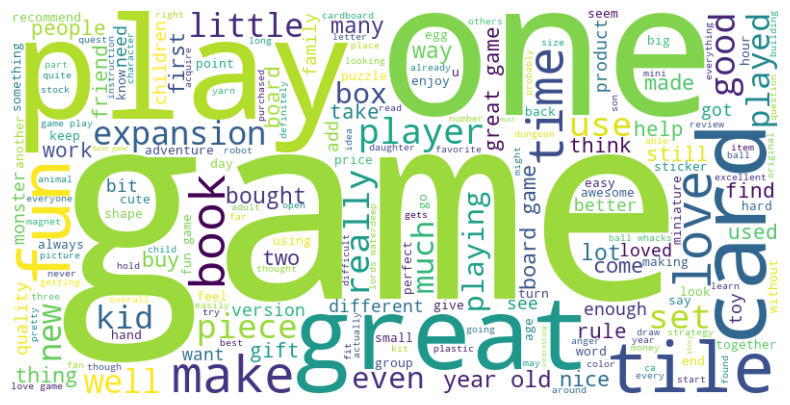

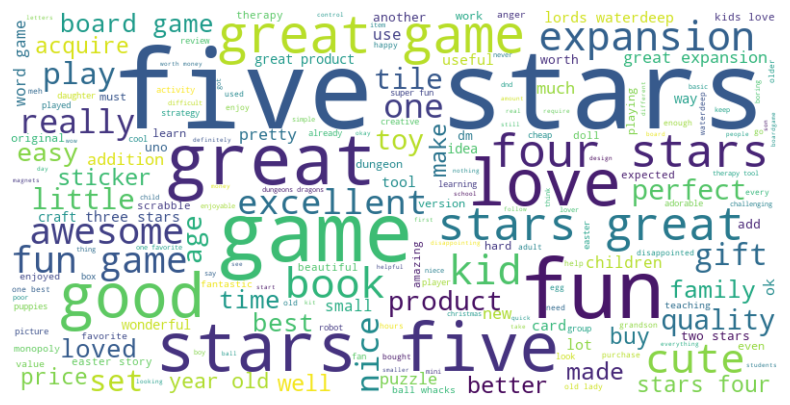

In [67]:
# Plot the wordcloud image.
plt.figure(figsize=(10, 5))
plt.imshow(review_wc_no_stopwords, interpolation='bilinear')
plt.axis('off')
plt.show()


plt.figure(figsize=(10, 5))
plt.imshow(summary_wc_no_stopwords, interpolation='bilinear')
plt.axis('off')
plt.show()

### 4d) Identify 15 most common words and polarity

In [68]:
# Determine the 15 most common words.
review_common_15 = FreqDist(review_filtered).most_common(15)
summary_common_15 = FreqDist(summary_filtered).most_common(15)

common_words_table = pd.DataFrame({
    'Review word': [word for word, count in review_common_15],
    'Review frequency': [count for word, count in review_common_15],
    'Summary word': [word for word, count in summary_common_15],
    'Summary frequency': [count for word, count in summary_common_15]})

common_words_table

,Review word,Review frequency,Summary word,Summary frequency
0,game,1696,stars,448
1,great,589,five,363
2,fun,555,game,318
3,one,532,great,294
4,play,504,fun,217
5,like,414,love,93
6,love,326,good,92
7,get,320,four,58
8,really,318,like,54
9,cards,301,expansion,52


## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [69]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [70]:
# Determine polarity of the 15 most common words in both columns.
from textblob import TextBlob

common_words_table['Review polarity'] = common_words_table['Review word'].apply(
    lambda word: TextBlob(word).sentiment.polarity)

common_words_table['Summary polarity'] = common_words_table['Summary word'].apply(
    lambda word: TextBlob(word).sentiment.polarity)

# View output.
common_words_table

,Review word,Review frequency,Summary word,Summary frequency,Review polarity,Summary polarity
0,game,1696,stars,448,-0.4,0.0
1,great,589,five,363,0.8,0.0
2,fun,555,game,318,0.3,-0.4
3,one,532,great,294,0.0,0.8
4,play,504,fun,217,0.0,0.3
5,like,414,love,93,0.0,0.5
6,love,326,good,92,0.5,0.7
7,get,320,four,58,0.0,0.0
8,really,318,like,54,0.2,0.0
9,cards,301,expansion,52,0.0,0.0


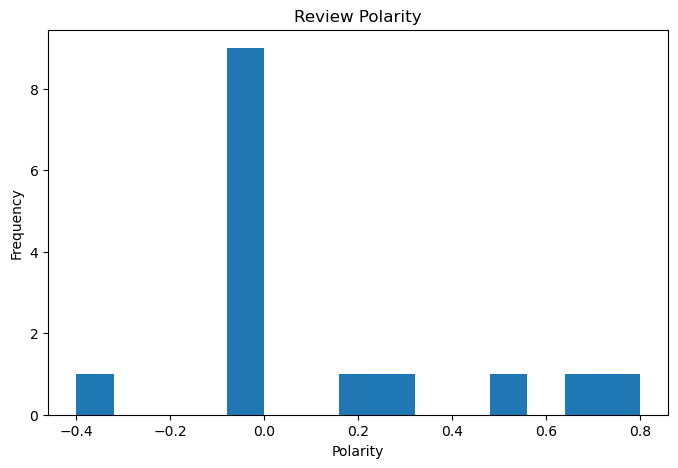

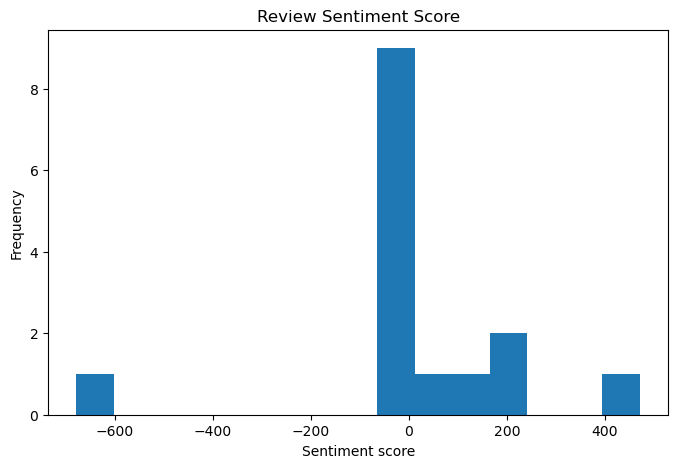

In [71]:
# Review: Create a histogram plot with bins = 15.

# Review: Calculate sentiment score.
common_words_table['Review sentiment score'] = (
    common_words_table['Review frequency'] *
    common_words_table['Review polarity'])

# Histogram of polarity.
plt.figure(figsize=(8, 5))
plt.hist(common_words_table['Review polarity'], bins=15)
plt.title('Review Polarity')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.show()

# Histogram of sentiment score.
plt.figure(figsize=(8, 5))
plt.hist(common_words_table['Review sentiment score'], bins=15)
plt.title('Review Sentiment Score')
plt.xlabel('Sentiment score')
plt.ylabel('Frequency')
plt.show()

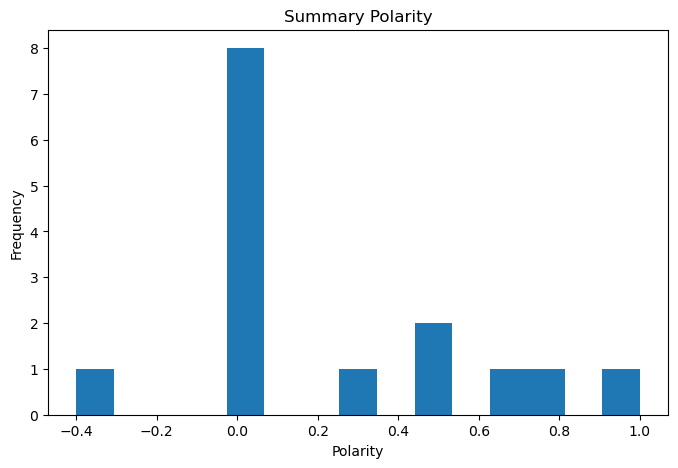

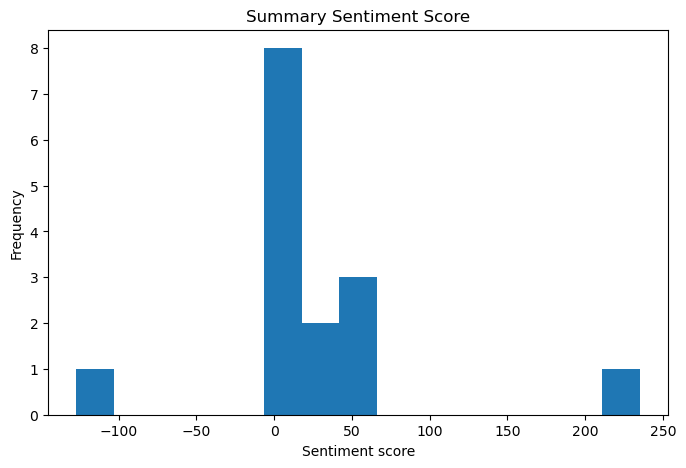

In [72]:
# Summary: Create a histogram plot with bins = 15.
# Summary: Calculate sentiment score.
common_words_table['Summary sentiment score'] = (
    common_words_table['Summary frequency'] *
    common_words_table['Summary polarity'])

# Histogram of polarity.
plt.figure(figsize=(8, 5))
plt.hist(common_words_table['Summary polarity'], bins=15)
plt.title('Summary Polarity')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.show()

# Histogram of sentiment score.
plt.figure(figsize=(8, 5))
plt.hist(common_words_table['Summary sentiment score'], bins=15)
plt.title('Summary Sentiment Score')
plt.xlabel('Sentiment score')
plt.ylabel('Frequency')
plt.show()

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [73]:
# Top 20 negative reviews.
df4_nlp['review_polarity'] = df4_nlp['review'].apply(generate_polarity)

top_20_negative_reviews = (
    df4_nlp[['review', 'review_polarity']]
    .sort_values(by='review_polarity')
    .head(20))

# View output.
top_20_negative_reviews.style.hide(axis='index')

review,review_polarity
BOOO UNLES YOU ARE PATIENT KNOW HOW TO MEASURE I DIDN'T HAVE THE PATIENCE NEITHER DID MY DAUGHTER. BORING UNLESS YOU ARE A CRAFT PERSON WHICH I AM NOT.,-1.000000
Incomplete kit! Very disappointing!,-0.975000
"If you, like me, used to play D&D, but now you and your friends ""growed up"" and can't be together because all the responsibilities and bla bla bla... this game is for you! Come to the Dungeon!",-0.625000
"I'm sorry. I just find this product to be boring and, to be frank, juvenile.",-0.583333
"One of my staff will be using this game soon, so I don't know how well it works as yet, but after looking at the cards, I believe it will be helpful in getting a conversation started regarding anger and what to do to control it.",-0.550000
Expensive for what you get.,-0.500000
I bought this as a Christmas gift for my grandson. Its a sticker book. So how can I go wrong with this gift.,-0.500000
Scrabble in a card game!,-0.500000
This game is a blast!,-0.500000
this was a gift for my daughter. I found it difficult to use,-0.500000


In [74]:
# Top 20 negative summaries.
df4_nlp['summary_polarity'] = df4_nlp['summary'].apply(generate_polarity)

top_20_negative_summaries = (
    df4_nlp[['summary', 'summary_polarity']]
    .sort_values(by='summary_polarity')
    .head(20))

# View output.
top_20_negative_summaries.style.hide(axis='index')

summary,summary_polarity
The worst value I've ever seen,-1.000000
BORING UNLESS YOU ARE A CRAFT PERSON WHICH I AM ...,-1.000000
Boring,-1.000000
before this I hated running any RPG campaign dealing with towns because it ...,-0.900000
Another worthless Dungeon Master's screen from GaleForce9,-0.800000
Disappointed.,-0.750000
Disappointed,-0.750000
Disappointed,-0.750000
Disappointed,-0.750000
Promotes anger instead of teaching calming methods,-0.700000


In [75]:
# Top 20 positive reviews.
top_20_positive_reviews = (
    df4_nlp[['review', 'review_polarity']]
    .sort_values(by='review_polarity', ascending=False)
    .head(20))

# View output.
top_20_positive_reviews.style.hide(axis='index')

review,review_polarity
Absolutely great pictures even before coloring!,1.000000
Perfect!,1.000000
It is great!!!,1.000000
great!!,1.000000
Awesome,1.000000
Delightful product!,1.000000
"this was perfect to go with the 7 bean bags , I just wish they were not separate orders.",1.000000
It's awesome,1.000000
"Great education ""toy""!",1.000000
One of the best board games I played in along time.,1.000000


In [76]:
# Top 20 positive summaries.
top_20_positive_summaries = (
    df4_nlp[['summary', 'summary_polarity']]
    .sort_values(by='summary_polarity', ascending=False)
    .head(20))

# View output.
top_20_positive_summaries.style.hide(axis='index')

summary,summary_polarity
Best One in the Series,1.000000
One of the best!,1.000000
The Easter Story Egg - A great idea!,1.000000
A wonderful reading resource.,1.000000
Awesome,1.000000
One of the best games EVER!,1.000000
... loves stickers and she loves Peppa so this was perfect..,1.000000
Awesome Book...,1.000000
Excellent On-The-Go Teaching Tool,1.000000
He was very happy with his gift,1.000000


## 7. Discuss: Insights and observations

The polarity distributions are concentrated around **0**, showing that most common words are neutral. However, frequent positive terms such as **great, fun, love, good, cute, and awesome** suggest generally favourable customer sentiment.

The extreme negative review score is mainly caused by **“game”**, which appears 1,696 times and was assigned a polarity of **-0.4**. Since sentiment score equals **frequency × polarity**, this creates a misleading result because “game” is not inherently negative in this context.

**Conclusion**

Overall sentiment appears neutral to positive, but the findings should be interpreted cautiously as the analysis covers only 15 individual words and does not consider whole context.

**Observations and insights Positive/Negative Reviews and Summary**

Negative reviews mainly concern **unclear instructions, difficult use or assembly, missing parts, poor quality and weak value for money.**
Positive reviews highlight fun, **educational value, gift suitability and usefulness for children, families and groups.**

Some reviews are misclassified, showing that TextBlob does not always understand context. Therefore, sentiment scores should support, rather than replace, manual review.

**Conclusion**

Marketing should emphasise **enjoyment, educational benefits and gift appeal**, while product improvements should focus on **clearer instructions, easier use, complete packaging and better perceived value.**